In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression  
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy import interpolate
import re
# 図のスタイル設定
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

import pickle
import japanize_matplotlib
from scipy.stats import pearsonr

import joblib
import plotly
# ▼▼▼ これを追加 ▼▼▼
plt.rcParams['font.family'] = 'MS Gothic'

In [2]:
with open(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\modelA_df_proc.pkl", "rb") as f:
    df_all = pickle.load(f)

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import TimeSeriesSplit, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, make_scorer


# ==========================================
# 1. SubjectAwareSmoother (平滑化)
# ==========================================
class SubjectAwareSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, window=15):
        self.window = window

    def _apply_rolling_mean(self, df):
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        cols_to_roll = [c for c in numeric_cols if c != 'subject_id']
        
        if 'subject_id' not in df.columns:
            return df[cols_to_roll].rolling(window=self.window, min_periods=1).mean()
        
        # GroupBy Rolling
        rolled = df.groupby('subject_id')[cols_to_roll].rolling(window=self.window, min_periods=1).mean()
        rolled = rolled.reset_index(level=0, drop=True).sort_index()
        return rolled

    def fit(self, X, y=None):
        return self

    def transform(self, X, X_context=None):
        X_out = X.copy()
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        target_cols = [c for c in numeric_cols if c != 'subject_id']

        if X_context is not None:
            X_combined = pd.concat([X_context.iloc[-self.window:], X])
            X_smooth_full = self._apply_rolling_mean(X_combined)
            X_smooth = X_smooth_full.iloc[-len(X):]
        else:
            X_smooth = self._apply_rolling_mean(X)
        
        X_out[target_cols] = X_smooth
        return X_out


# ==========================================
# 1. SubjectAwareSmoother (EMA: 指数移動平均版)
# ==========================================
class SubjectAwareSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, window=15):
        """
        window: EMAの span に相当 (SMAのwindowとほぼ同等の平滑化度合い)
        """
        self.window = window

    def _apply_ema(self, df):
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        cols_to_smooth = [c for c in numeric_cols if c != 'subject_id']
        
        if 'subject_id' not in df.columns:
            # span=window で直近を重視しつつ平滑化
            return df[cols_to_smooth].ewm(span=self.window, min_periods=1).mean()
        
        # GroupBy EMA
        # Pandasのバージョンによって groupby().ewm() の挙動が異なる場合があるため
        # 確実な実装としてループまたは apply を使用 (ここでは高速なGroupBy Apply)
        
        # 関数定義
        def ema_func(x):
            return x.ewm(span=self.window, min_periods=1).mean()

        # subjectごとに適用して結合
        rolled = df.groupby('subject_id')[cols_to_smooth].apply(ema_func)
        
        # MultiIndex解除 (subject_idがインデックスに残る場合があるため)
        if isinstance(rolled.index, pd.MultiIndex):
            rolled = rolled.reset_index(level=0, drop=True)
            
        return rolled.sort_index()

    def fit(self, X, y=None):
        return self

    def transform(self, X, X_context=None):
        X_out = X.copy()
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        target_cols = [c for c in numeric_cols if c != 'subject_id']

        if X_context is not None:
            # EMAは過去を引きずるため、長めのコンテキストをつける(windowの3倍程度)
            X_combined = pd.concat([X_context.iloc[-self.window*3:], X])
            X_smooth_full = self._apply_ema(X_combined)
            X_smooth = X_smooth_full.iloc[-len(X):]
        else:
            X_smooth = self._apply_ema(X)
        
        X_out[target_cols] = X_smooth
        return X_out

# ==========================================
# 2. SubjectAwareDetrender (選択的デトレンド: SMA版)
# ==========================================
class SubjectAwareDetrender(BaseEstimator, TransformerMixin):
    def __init__(self, window=300, target_cols=None):
        """
        window: トレンド推定用のウィンドウサイズ (SMA)
        target_cols: デトレンドを実施するカラム名のリスト。Noneの場合は全数値列。
        """
        self.window = window
        self.target_cols = target_cols

    def _calculate_trend(self, df, cols):
        # トレンド除去は「ゆっくりした変化」を取りたいので、
        # あえて反応の遅い rolling().mean() (SMA) を使うのが定石
        if 'subject_id' not in df.columns:
            return df[cols].rolling(window=self.window, min_periods=1).mean()
        
        rolled = df.groupby('subject_id')[cols].rolling(window=self.window, min_periods=1).mean()
        rolled = rolled.reset_index(level=0, drop=True).sort_index()
        return rolled

    def fit(self, X, y=None):
        return self

    def transform(self, X, X_context=None):
        X_out = X.copy()
        
        # 処理対象カラムの特定
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        
        if self.target_cols is None:
            process_cols = [c for c in numeric_cols if c != 'subject_id']
        else:
            # データフレームに存在するカラムのみ抽出
            process_cols = [c for c in self.target_cols if c in X.columns]
            
        if len(process_cols) == 0:
            return X_out

        # コンテキスト結合とトレンド計算
        if X_context is not None:
            X_combined = pd.concat([X_context.iloc[-self.window:], X])
            trend_full = self._calculate_trend(X_combined, process_cols)
            trend = trend_full.iloc[-len(X):]
        else:
            trend = self._calculate_trend(X, process_cols)

        # 引き算 (対象カラムのみ更新)
        # ※ fillna(0) はトレンドが計算できない最序盤の対策（必要に応じて）
        X_out[process_cols] = X_out[process_cols] - trend.fillna(0)
        
        return X_out


# ==========================================
# 4. SubjectAwareStandardizer (標準化)
# ==========================================
class SubjectAwareStandardizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.stats_per_subject = {} 
        self.global_stats = {}      
        self.target_cols = []

    def fit(self, X, y=None):
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        self.target_cols = [c for c in numeric_cols if c != 'subject_id']

        # 1. Global Stats
        for col in self.target_cols:
            mean, std = X[col].mean(), X[col].std()
            if std == 0: std = 1.0
            self.global_stats[col] = (mean, std)

        # 2. Subject Stats
        if 'subject_id' in X.columns:
            grouped = X.groupby('subject_id')[self.target_cols].agg(['mean', 'std'])
            for subject_id, row in grouped.iterrows():
                self.stats_per_subject[subject_id] = {}
                for col in self.target_cols:
                    m = row[(col, 'mean')]
                    s = row[(col, 'std')]
                    if pd.isna(s) or s == 0: s = 1.0
                    self.stats_per_subject[subject_id][col] = (m, s)
        return self

    def transform(self, X):
        X_out = X.copy()
        
        # Subjectが無い場合
        if 'subject_id' not in X.columns:
            for col in self.target_cols:
                if col in X_out.columns:
                    m, s = self.global_stats[col]
                    X_out[col] = (X_out[col] - m) / s
            return X_out

        # Subjectがある場合 (Mapによる高速化)
        for col in self.target_cols:
            if col not in X_out.columns: continue

            mean_map, std_map = {}, {}
            g_mean, g_std = self.global_stats[col]

            for uid in X_out['subject_id'].unique():
                if uid in self.stats_per_subject:
                    mean_map[uid] = self.stats_per_subject[uid][col][0]
                    std_map[uid]  = self.stats_per_subject[uid][col][1]
                else:
                    mean_map[uid] = g_mean
                    std_map[uid]  = g_std
            
            means = X_out['subject_id'].map(mean_map)
            stds  = X_out['subject_id'].map(std_map)
            X_out[col] = (X_out[col] - means) / stds

        return X_out

# ==========================================
# SubjectAwareInitialBiasSubtractor (初期値除去)
# ==========================================
class SubjectAwareInitialBiasSubtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_samples=50):
        self.n_samples = n_samples
        self.bias_per_subject = {}

    def fit(self, X, y=None):
        return self

    def transform(self, X, X_context=None):
        """
        Subjectごとに開始n_samplesの平均を計算して引く
        X_context (過去データ) がある場合は、
        文脈としてそれを含めたデータの「先頭」を基準にするか、
        あるいはX単体の先頭を基準にするかの設計が必要ですが、
        ここでは「渡されたデータの先頭」を基準にします。
        """
        X_out = X.copy()
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        target_cols = [c for c in numeric_cols if c != 'subject_id']

        # Subjectがない場合は全体で処理
        if 'subject_id' not in X.columns:
            bias = X[target_cols].iloc[:self.n_samples].mean()
            X_out[target_cols] = X_out[target_cols] - bias
            return X_out

        # Subjectがある場合
        # GroupByで処理すると遅くなる＆インデックス再構築が面倒なため、
        # Subjectごとにループしてバイアスを計算・適用する
        for uid in X['subject_id'].unique():
            # そのSubjectのマスクを作成
            mask = (X['subject_id'] == uid)
            
            # そのSubjectのデータだけ抽出
            subset = X.loc[mask, target_cols]
            
            # コンテキスト(過去データ)がある場合、それと結合したものの先頭を使うべきだが、
            # ここでは「入力データの先頭50個」をキャリブレーションとする
            # (もし厳密に「過去の続き」として処理したい場合はX_contextを使うロジックを追加)
            if len(subset) > 0:
                # バイアス計算 (先頭 n_samples の平均)
                bias = subset.iloc[:self.n_samples].mean()
                
                # 引き算
                X_out.loc[mask, target_cols] = subset - bias

        return X_out

# ==========================================
# 5. SimplePLSModel
# ==========================================
class SimplePLSModel:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.model = None

    def fit(self, X, y):
        self.model = PLSRegression(n_components=min(self.n_components, X.shape[1]))
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)


from sklearn.model_selection import KFold, GroupKFold, cross_val_score

class AutoTunedPLSModel:
    def __init__(self, max_components=20, cv_splits=5, cv_method='random'):
        """
        cv_method: 'random' (KFold) or 'group' (GroupKFold)
        """
        self.max_components = max_components
        self.cv_splits = cv_splits
        self.cv_method = cv_method
        self.best_n_components_ = None
        self.model = None

    def fit(self, X, y, groups=None):
        """
        groups: Inner CVで GroupKFold を使うためのグルーピング情報 (subject_id等)
        """
        # 探索範囲
        n_features = X.shape[1]
        limit = min(n_features, self.max_components)
        if limit < 1: limit = 1
        candidate_components = range(1, limit + 1)
        
        best_score = float('inf')
        best_n = 1
        
        # CV分割器の選択
        if self.cv_method == 'group':
            if groups is None:
                raise ValueError("cv_method='group' requires 'groups' argument in fit().")
            
            # グループ数がsplit数より少ない場合の安全策
            n_groups = len(np.unique(groups))
            actual_splits = min(self.cv_splits, n_groups)
            
            cv = GroupKFold(n_splits=actual_splits)
        else:
            # ランダム分割 (従来通り)
            cv = KFold(n_splits=self.cv_splits, shuffle=True, random_state=42)
        
        # グリッドサーチ
        for n in candidate_components:
            pls = PLSRegression(n_components=n, scale=False)
            
            # groups引数は、KFoldの場合は無視され、GroupKFoldの場合のみ使われる
            scores = cross_val_score(pls, X, y, cv=cv, groups=groups, scoring='neg_mean_squared_error')
            mse_score = -np.mean(scores)
            
            if mse_score < best_score:
                best_score = mse_score
                best_n = n
        
        # 最適値で学習
        self.best_n_components_ = best_n
        self.model = PLSRegression(n_components=best_n, scale=False)
        self.model.fit(X, y)
        
        return self

    def predict(self, X):
        return self.model.predict(X)

from sklearn.metrics import mean_squared_error,mean_absolute_error # 追加
def plot_prediction_waveform(y_true, y_pred, y_col, fold_id=None, score=None, mae=None, rmse=None):
    """
    RMSE引数を追加
    """
    plt.figure(figsize=(15, 4))
    
    plt.plot(y_true.values, label="True", linewidth=2, alpha=0.85)
    plt.plot(y_pred.values, label="Pred", linewidth=1.5, linestyle='--', alpha=0.85)
    
    title_parts = [f"Prediction vs True - {y_col}"]
    if fold_id is not None:
        title_parts.append(f"({fold_id})")
    
    score_text = []
    if score is not None: score_text.append(f"R2={score:.3f}")
    if mae is not None:   score_text.append(f"MAE={mae:.3f}")
    if rmse is not None:  score_text.append(f"RMSE={rmse:.3f}") # ★追加
        
    if score_text:
        title_parts.append(" | " + ", ".join(score_text))
        
    plt.title(" ".join(title_parts), fontsize=14)
    plt.xlabel("Time (samples)")
    plt.ylabel(y_col)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    
def plot_feature_importance(pls_model, feature_names, y_col):
    """
    PLS の特徴量重要度を棒グラフで可視化する
    - pls_model : SimplePLSModel.model (PLSRegression)
    - feature_names : X の列名
    - y_col : どのターゲット向けのモデルか
    """
    # 係数を取得（shape: n_features x n_targets）
    coefs = pls_model.coef_.flatten()

    # 重要度 = |係数|
    importance = np.abs(coefs)

    # 大きい順にソート
    idx = np.argsort(importance)[::-1]
    sorted_importance = importance[idx]
    sorted_features = np.array(feature_names)[idx]

    plt.figure(figsize=(10, 5))
    plt.bar(sorted_features[:20], sorted_importance[:20])  # 上位20個だけ描画（多すぎるため）
    plt.xticks(rotation=90)
    plt.title(f"Feature Importance (PLS coef) for {y_col}")
    plt.tight_layout()
    plt.show()
    

def plot_residual_acorrelation(y_true, y_pred, y_col):
    """
    残差の自己相関（Autocorrelation）をプロットする関数
    修正点: y_true が DataFrame の場合に Series に変換する処理を追加
    """
    # ★修正: y_true が DataFrame なら Series (1次元) に変換する
    if isinstance(y_true, pd.DataFrame):
        # 1列目のデータをSeriesとして取り出す
        y_true = y_true.iloc[:, 0]
    
    # 残差の計算 (Series同士の計算になるので安全)
    resid = y_true - y_pred
    
    # NaNや無限大が含まれているとエラーになるので除去
    resid = resid.dropna()
    resid = resid[np.isfinite(resid)]
    
    # numpy array に変換して flatten (念には念を入れて1次元化)
    resid_values = resid.values.flatten()

    plt.figure(figsize=(10, 5))
    
    # acorrプロット
    # maxlags: データ点数が少ない場合は len(resid)//2 程度に抑えるのが安全
    lags = min(50, len(resid_values) // 2)
    
    plt.acorr(resid_values, maxlags=lags, usevlines=True, normed=True, lw=2)
    
    plt.title(f"Residual Autocorrelation - {y_col} (Check for Spurious Regression)")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.2, 1.1) 
    
    # 目安ライン
    plt.axhline(0, color='black', lw=1)
    plt.axhline(0.1, color='red', linestyle='--', alpha=0.3)
    plt.axhline(-0.1, color='red', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# B. 通常学習用 (新規追加)
# ==========================================
def plot_simple_waveform(y_true, y_pred, y_col, fold_id=None, score=None, mae=None, rmse=None):
    """
    """
    plt.figure(figsize=(15, 5))
    
    plt.plot(y_true.values, label="True", color='black', alpha=0.75, linewidth=1.5)
    plt.plot(y_pred.values, label="Pred", color='red', linestyle='--', alpha=0.85, linewidth=1.5)
    
    title_parts = [f"Prediction vs True - {y_col}"]
    if fold_id is not None:
        title_parts.append(f"({fold_id})")
    
    score_text = []
    if score is not None: score_text.append(f"R2={score:.3f}")
    if mae is not None:   score_text.append(f"MAE={mae:.3f}")
    if rmse is not None:  score_text.append(f"RMSE={rmse:.3f}")
        
    if score_text:
        title_parts.append(" | " + ", ".join(score_text))
        
    plt.title(" ".join(title_parts), fontsize=14)
    plt.xlabel("Time (samples)")
    plt.ylabel(y_col)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer # ★追加

# ==========================================
# STEP 1: HierarchicalPLSモデルのクラス定義
# ==========================================
class HierarchicalPLSModel:
    """
    階層的混合モデル: 共通パターン + 被験者ごとの補正
    """
    def __init__(self, n_components=15, use_gain=True, use_offset=True):
        self.n_components = n_components
        self.use_gain = use_gain
        self.use_offset = use_offset
        self.global_pls = None
        self.subject_gains = {}
        self.subject_offsets = {}
        self.default_gain = 1.0
        self.default_offset = 0.0
        self.imputer = SimpleImputer(strategy='mean')
        
    def fit(self, X, y, subjects):
        """
        学習
        X: (n_samples, n_features) - 被験者IDを含まない数値データ
        y: (n_samples,) or (n_samples, 1)
        subjects: (n_samples,) - 被験者ID配列
        """
        if len(y.shape) > 1:
            y = y.flatten()
        
        X = self.imputer.fit_transform(X)

        # Stage 1: グローバルPLS
        print(f"    [Stage 1] Training Global PLS (n_components={self.n_components})...")
        self.global_pls = PLSRegression(n_components=self.n_components, scale=False)
        self.global_pls.fit(X, y)
        y_global = self.global_pls.predict(X).flatten()
        
        # Stage 2: 被験者ごとの補正パラメータ
        print(f"    [Stage 2] Fitting Subject-specific corrections...")
        unique_subjects = np.unique(subjects)
        all_gains, all_offsets = [], []
        
        for subj in unique_subjects:
            mask = (subjects == subj)
            y_true_subj = y[mask]
            y_global_subj = y_global[mask]

            # 安全対策: データが少なすぎる、または分散がない場合はスキップしてデフォルト値にする
            if len(y_true_subj) < 2 or np.std(y_global_subj) < 1e-6:
                gain, offset = 1.0, 0.0
            else:
                if self.use_gain and self.use_offset:
                    A = np.column_stack([y_global_subj, np.ones(len(y_global_subj))])
                    params = np.linalg.lstsq(A, y_true_subj, rcond=None)[0]
                    gain, offset = params[0], params[1]
                elif self.use_gain:
                    gain = np.sum(y_true_subj * y_global_subj) / (np.sum(y_global_subj ** 2) + 1e-8)
                    offset = 0.0
                elif self.use_offset:
                    gain = 1.0
                    offset = np.mean(y_true_subj - y_global_subj)
                else:
                    gain, offset = 1.0, 0.0

            self.subject_gains[subj] = gain
            self.subject_offsets[subj] = offset
            all_gains.append(gain)
            all_offsets.append(offset)
        
        self.default_gain = np.median(all_gains)
        self.default_offset = np.median(all_offsets)
        
        print(f"    Gain: [{np.min(all_gains):.3f}, {np.max(all_gains):.3f}], median={self.default_gain:.3f}")
        print(f"    Offset: [{np.min(all_offsets):.3f}, {np.max(all_offsets):.3f}], median={self.default_offset:.3f}")
        return self
    
    def predict(self, X, subjects):
        """予測"""
        X = self.imputer.transform(X)
        y_global = self.global_pls.predict(X).flatten()
        y_corrected = np.zeros_like(y_global)

        # subjectsが単一の値（スカラー）で来る場合の対応
        if np.isscalar(subjects):
            subjects = np.full(len(X), subjects)
        
        for subj in np.unique(subjects):
            mask = (subjects == subj)
            gain = self.subject_gains.get(subj, self.default_gain)
            offset = self.subject_offsets.get(subj, self.default_offset)
            y_corrected[mask] = gain * y_global[mask] + offset
        
        return y_corrected
    
    def get_global_prediction(self, X):
        """グローバルPLSのみの予測（診断用）"""
        X = self.imputer.transform(X)
        return self.global_pls.predict(X).flatten()


class AutoTunedHierarchicalPLS:
    """最適成分数を自動選択"""
    def __init__(self, max_components=20, cv_splits=5, use_gain=True, use_offset=True):
        self.max_components = max_components
        self.cv_splits = cv_splits
        self.use_gain = use_gain
        self.use_offset = use_offset
        self.best_n_components_ = None
        self.model = None
    
    def fit(self, X, y, subjects):
        if len(y.shape) > 1:
            y = y.flatten()
        
        n_features = X.shape[1]
        limit = min(n_features, self.max_components)
        candidate_components = range(1, limit + 1)
        
        n_groups = len(np.unique(subjects))
        actual_splits = min(self.cv_splits, n_groups)
        gkf = GroupKFold(n_splits=actual_splits)
        
        best_score = float('inf')
        best_n = 1
        
        print(f"    [Auto-tuning] Testing n_components from 1 to {limit}...")
        
        for n in candidate_components:
            scores = []
            for train_idx, val_idx in gkf.split(X, y, groups=subjects):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]
                subj_train, subj_val = subjects[train_idx], subjects[val_idx]
                
                model = HierarchicalPLSModel(n, self.use_gain, self.use_offset)
                model.fit(X_train, y_train, subj_train)
                y_pred_val = model.predict(X_val, subj_val)
                scores.append(mean_squared_error(y_val, y_pred_val))
            
            avg_mse = np.mean(scores)
            if avg_mse < best_score:
                best_score = avg_mse
                best_n = n
        
        print(f"    [Auto-tuning] Best n_components = {best_n} (MSE={best_score:.4f})")
        
        self.best_n_components_ = best_n
        self.model = HierarchicalPLSModel(best_n, self.use_gain, self.use_offset)
        self.model.fit(X, y, subjects)
        return self
    
    def predict(self, X, subjects):
        return self.model.predict(X, subjects)
    
    def get_global_prediction(self, X):
        return self.model.get_global_prediction(X)



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# -----------------------------------------------------------------------------
# Complete Pipeline Class
# -----------------------------------------------------------------------------
class SubjectAwarePipeline:
    def __init__(self, config):
        """
        config: 設定辞書
          - enable_smoothing: (bool) スムージングの有無
          - enable_bias_sub: (bool) 初期値引きの有無
          - scale_y: (bool) 目的変数のスケーリング有無
          - show_plots: (bool) 学習ループごとの波形プロット有無
          - show_importance: (bool) 特徴量重要度のプロット有無
          - smooth_window, bias_window, n_components ...
        """
        self.config = config
        self.trained_models = {} 
        self.df_result = None # 最終結果格納
        
        # --- 機能 ON/OFF ---
        self.enable_smoothing = config.get('enable_smoothing', True)
        self.enable_detrending = config.get('enable_detrending', True)
        self.enable_bias_sub  = config.get('enable_bias_sub', True)
        self.enable_scale_x   = config.get('scale_x', True)
        self.enable_scale_y   = config.get('scale_y', False)
        self.show_plots       = config.get('show_plots', True)       # ★学習中の波形
        self.show_importance  = config.get('show_importance', True)  # ★重要度
        
        # --- プロセッサ初期化 (クラス定義は外部にある前提) ---
        self.smoother = SubjectAwareSmoother(window=config.get('smooth_window', 15)) # 1. Smoother (EMA) - 全特徴量にかけてOK (ノイズ除去)
        # 2. Detrender (Selective SMA) - ドリフト成分のみ除去
        self.detrender = SubjectAwareDetrender(
            window=config.get('detrend_window', 300),
            target_cols=config.get('detrend_cols', None) # ここでリストを渡す
        )
        # 3. Bias Subtractor - 全特徴量の初期オフセット除去
        self.bias_subtractor = SubjectAwareInitialBiasSubtractor(n_samples=config.get('bias_window', 60))
        self.scaler_cls = SubjectAwareStandardizer
    
    def _preprocess(self, X, y=None, context_X=None, context_y=None):
        """
        前処理パイプライン
        context_X/y: 時系列の連続性を保つために、直前のデータ(学習データの末尾など)を渡す
        """
        X_out = X.copy()
        y_out = y.copy() if y is not None else None

        # 1. Smoothing (Context対応)
        if self.enable_smoothing:
            # 学習時はContextなし、テスト時はContextあり(指定されていれば)
            X_out = self.smoother.transform(X_out, X_context=context_X)
            if y_out is not None: 
                # yのsmoothにも、yのcontext (過去のy) を渡す
                # smootherの引数名は X_context だが、ここに y_context を渡す想定
                y_out = self.smoother.transform(y_out, X_context=context_y)

        # 2. Selective Detrending (Target Cols Only)
        # y(目的変数)には通常デトレンドはかけない（あるいは別設定）とする
        if self.enable_detrending:
            X_out = self.detrender.transform(X_out, X_context=context_X)

        # 3. Bias Subtraction
        # Biasは通常、セッションごとにリセットして計算するためContextは渡さない
        if self.enable_bias_sub:
            X_out = self.bias_subtractor.transform(X_out)
            # if y_out is not None: y_out = self.bias_subtractor.transform(y_out) # やってはいけない

        return X_out, y_out

    def fit(self, X_raw, y_raw, holdout_subject_ids=None):
        """学習メインループ"""
        print("=" * 60)
        print(f"🚀 Pipeline Start | Plots: {self.show_plots} | Importance: {self.show_importance}")

        all_results_list = [] # 結果蓄積用リスト
        
        # ID列チェック
        if 'subject_id' not in X_raw.columns:
            X_raw = X_raw.assign(subject_id=1)

        # 分割ロジック
        is_timeseries_mode = False # フラグ管理
        if holdout_subject_ids is not None:
            mask_test = X_raw['subject_id'].isin(holdout_subject_ids)
            train_idx = np.where(~mask_test)[0]
            test_idx  = np.where(mask_test)[0]
            cv_splits = [(train_idx, test_idx)]
            print(f"🚀 分割ロジック: Hold-out Subject Mode (Test IDs: {holdout_subject_ids})")
        else:
            tscv = TimeSeriesSplit(n_splits=self.config.get('cv_splits', 3))
            cv_splits = tscv.split(X_raw)
            is_timeseries_mode = True # 時系列モードON
            print(f"🚀 分割ロジック: TimeSeriesSplit Mode")

        # --- CV Loop ---
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"\n--- Fold {fold+1} ---")
            
            # 生データ切り出し
            X_train_raw = X_raw.iloc[train_idx].copy()
            y_train_raw = y_raw.iloc[train_idx].copy()
            X_test_raw = X_raw.iloc[test_idx].copy()
            y_test_raw = y_raw.iloc[test_idx].copy()

            y_train_raw['subject_id'] = X_train_raw['subject_id']
            y_test_raw['subject_id'] = X_test_raw['subject_id']

            # ▼▼▼ 文脈データの準備 ▼▼▼
            if is_timeseries_mode:
                # TimeSeriesSplitの場合、Testの前にはTrainがある -> TrainをContextにする
                ctx_X = X_train_raw
                ctx_y = y_train_raw
            else:
                # Subject Hold-outの場合、被験者が違うので文脈は切れる -> None
                ctx_X = None
                ctx_y = None

            # 前処理 (Smooth -> BiasSub)
            X_train, y_train = self._preprocess(X_train_raw, y_train_raw, context_X=None, context_y=None)
            X_test, y_test   = self._preprocess(X_test_raw, y_test_raw, context_X=ctx_X, context_y=ctx_y)


            
            # --- Target Loop ---
            for target_col in [c for c in y_raw.columns if c != 'subject_id']:
                
                # 欠損除去 & データ結合

                y_train_target = y_train[[target_col, 'subject_id']]
                y_test_target = y_test[[target_col, 'subject_id']]
                common_idx_train = X_train.dropna().index.intersection(y_train_target.dropna().index)
                X_train_clean = X_train.loc[common_idx_train]
                y_train_clean = y_train_target.loc[common_idx_train]
                common_idx_test = X_test.dropna().index.intersection(y_test_target.dropna().index)
                X_test_clean = X_test.loc[common_idx_test]
                y_test_clean = y_test_target.loc[common_idx_test]

                # if len(train_data) < 100 or len(test_data) == 0:
                #     continue
                
                # Input Scaling
                scaler_x = None
                if self.enable_scale_x:
                    scaler_x = self.scaler_cls()
                    scaler_x.fit(X_train_clean)
                    X_train_final = scaler_x.transform(X_train_clean).drop(columns=['subject_id'], errors='ignore')
                    X_test_final = scaler_x.transform(X_test_clean).drop(columns=['subject_id'], errors='ignore')
                
                # Output Scaling (Optional)
                scaler_y = None
                y_train_final = y_train_clean.drop(columns=['subject_id'], errors='ignore')
                y_test_final  = y_test_clean.drop(columns=['subject_id'], errors='ignore')
                if self.enable_scale_y:
                    scaler_y = self.scaler_cls()
                    scaler_y.fit(y_train_clean)
                    y_train_final = scaler_y.transform(y_train_clean).drop(columns=['subject_id'], errors='ignore')
                    y_test_final  = scaler_y.transform(y_test_clean).drop(columns=['subject_id'], errors='ignore')

                # Model Fitting
                model = self._get_model_instance()

                # 被験者ID情報を取得
                train_subjects = X_train_clean['subject_id'].values
                test_subjects = X_test_clean['subject_id'].values

                if isinstance(model, (HierarchicalPLSModel, AutoTunedHierarchicalPLS)):
                    # Hierarchicalモデルの場合
                    model.fit( X_train_final.values, y_train_final.values, train_subjects
                    )
                else:
                    # 既存のPLS（標準）
                    groups = train_subjects
                    if hasattr(model, 'fit') and 'groups' in model.fit.__code__.co_varnames:
                        model.fit(X_train_final, y_train_final, groups=groups)
                    else:
                        model.fit(X_train_final, y_train_final)


                # -------------------------
                # 4. 結果格納用の内部関数
                # -------------------------
                def _process_result(X_feat, y_clean, subjects_arr, data_type_str):
                    """
                    X_feat: スケーリング済み特徴量
                    y_clean: スケーリング前(生単位)の正解データ
                    data_type_str: 'train' or 'test'
                    """
                    if len(X_feat) == 0: return None
                    
                    # 推論 (OutputはScaled状態)
  
                        # ★推論部分を修正
                    if isinstance(model, (HierarchicalPLSModel, AutoTunedHierarchicalPLS)):
                        pred_scaled = model.predict(X_feat.values, subjects_arr).flatten()
                    else:
                        pred_scaled = model.predict(X_feat).flatten()
                                    
                    # 評価用にスケールを戻す (Original Unit)
                    if self.enable_scale_y and scaler_y:
                        pred_val = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
                    else:
                        pred_val = pred_scaled
                    
                    true_val = y_clean[target_col].values
                    
                    # DataFrame作成
                    df_res = pd.DataFrame(index=X_feat.index)
                    df_res['time'] = df_res.index
                    df_res['fold番号'] = fold + 1
                    df_res['subject_id'] = y_clean['subject_id'].values
                    df_res['target_name'] = target_col
                    df_res['data_type'] = data_type_str  # ★ train / test
                    
                    # 特徴量 (_feature suffix)
                    for c_name in X_feat.columns:
                        df_res[f"{c_name}_feature"] = X_feat[c_name].values
                    
                    # 真値・予測値・残差
                    df_res[f"{target_col}_true"] = true_val
                    df_res[f"{target_col}_pred"] = pred_val
                    df_res[f"{target_col}_residual"] = true_val - pred_val
                    
                    return df_res

                # -------------------------
                # 5. Train/Test それぞれの結果を作成
                # -------------------------
                # 学習データの結果
                # df_res_train = _process_result(X_train_final, y_train_clean, 'train')
                # df_res_test  = _process_result(X_test_final,  y_test_clean,  'test')
                df_res_train = _process_result(X_train_final, y_train_clean, train_subjects, 'train')  # ★ train_subjects 追加
                df_res_test  = _process_result(X_test_final,  y_test_clean,  test_subjects,  'test')   # ★ test_subjects 追加
                
                # リストに追加
                if df_res_train is not None: all_results_list.append(df_res_train)
                if df_res_test is not None:  all_results_list.append(df_res_test)

                # -------------------------
                # 6. 簡易レポート & プロット (Testがある場合のみ)
                # -------------------------
                if df_res_test is not None:
                    # R2スコア計算
                    r2_test = r2_score(df_res_test[f"{target_col}_true"], df_res_test[f"{target_col}_pred"])
                    print(f"   Target: {target_col:<15} | Test R2: {r2_test:.4f}")
                    
                    # プロット
                    if self.show_plots:
                        self._plot_waveform(
                            df_res_test[f"{target_col}_true"], 
                            df_res_test[f"{target_col}_pred"], 
                            f"{target_col} (Fold {fold+1})", r2_test
                        )
                
                # Feature Importance
                if self.show_importance:
                    self._plot_feature_importance(model, X_train_final.columns, target_col)
                
                # Artifacts保存
                self.trained_models[target_col] = {
                    'model': model, 'scaler_x': scaler_x, 'scaler_y': scaler_y
                }

                

        # -------------------------
        # 7. 最終結合
        # -------------------------
        if len(all_results_list) > 0:
            self.df_result = pd.concat(all_results_list, axis=0)
            print("\n✅ Training Complete. Results saved to self.df_result (Includes Train & Test)")
        else:
            self.df_result = pd.DataFrame()
            print("\n⚠️ No results collected.")


        return self

    def diagnose(self, X_raw, y_raw, target_subjects=None):
        """
        犯人捜し診断: 被験者ごとの散布図を描画し、ランキングを表示する
        """
        if target_subjects is None:
            target_subjects = X_raw['subject_id'].unique()
            
        print(f"\n🔍 Starting Diagnosis for {len(target_subjects)} subjects...")
        
        # データ抽出 & Preprocess (自身のデータで前処理)
        mask = X_raw['subject_id'].isin(target_subjects)
        X_proc, y_proc = self._preprocess(X_raw[mask].copy(), y_raw[mask].copy())
        
        diag_results = {}

        for target_col, artifact in self.trained_models.items():
            if target_col not in y_proc.columns: continue
            
            # --- Inference ---
            model = artifact['model']
            scaler_x = artifact['scaler_x']
            scaler_y = artifact['scaler_y']
            
            data = pd.concat([X_proc, y_proc[[target_col]]], axis=1).dropna()
            if len(data) == 0: continue
            
            X_clean = data[X_proc.columns]
            y_true  = data[target_col].values
            current_subjects = data['subject_id'].values
            
            # Scale & Predict
            # X_in = scaler_x.transform(X_clean).drop(columns=['subject_id'], errors='ignore')
            # y_pred = model.predict(X_in).flatten()
            # if self.enable_scale_y and scaler_y:
            #     y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()
            X_in = scaler_x.transform(X_clean).drop(columns=['subject_id'], errors='ignore')

            # ★ Hierarchicalモデルの場合は被験者IDも渡す
            if isinstance(model, (HierarchicalPLSModel, AutoTunedHierarchicalPLS)):
                y_pred = model.predict(X_in.values, current_subjects).flatten()
            else:
                y_pred = model.predict(X_in).flatten()
            
            # Overall Score
            r2 = r2_score(y_true, y_pred)
            diag_results[target_col] = r2
            
            # ★ 散布図プロット
            self._plot_diagnosis(y_true, y_pred, current_subjects, target_col, r2)
        
        return diag_results
    
    # -------------------------------------------------------------------------
    # ★ 追加機能: インタラクティブな診断プロット (Plotly)
    # -------------------------------------------------------------------------
    def diagnose_interactive(self, X_raw, y_raw, target_subjects=None):
        """
        Plotlyを使って、クリックで表示/非表示ができるインタラクティブな散布図を描画する
        """
        import plotly.express as px

        if target_subjects is None:
            target_subjects = X_raw['subject_id'].unique()
            
        print(f"\n🔍 Starting Interactive Diagnosis for {len(target_subjects)} subjects...")
        
        # データ抽出 & Preprocess
        mask = X_raw['subject_id'].isin(target_subjects)
        X_proc, y_proc = self._preprocess(X_raw[mask].copy(), y_raw[mask].copy())
        
        for target_col, artifact in self.trained_models.items():
            if target_col not in y_proc.columns: continue
            
            # 推論実行
            model = artifact['model']
            scaler_x = artifact['scaler_x']
            scaler_y = artifact['scaler_y']
            
            data = pd.concat([X_proc, y_proc[[target_col]]], axis=1).dropna()
            if len(data) == 0: continue
            
            X_clean = data[X_proc.columns]
            y_true  = data[target_col].values
            current_subjects = data['subject_id'].values
            
            # Predict
            # X_in = scaler_x.transform(X_clean).drop(columns=['subject_id'], errors='ignore')
            # y_pred = model.predict(X_in).flatten()
            # if self.enable_scale_y and scaler_y:
            #     y_pred = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()
            # ★ Hierarchicalモデルの場合は被験者IDも渡す
            if isinstance(model, (HierarchicalPLSModel, AutoTunedHierarchicalPLS)):
                y_pred = model.predict(X_in.values, current_subjects).flatten()
            else:
                y_pred = model.predict(X_in).flatten()
            
            r2 = r2_score(y_true, y_pred)
            best_n_info = ""
            if hasattr(model, 'best_n_components_'):
                best_n_info = f" | Best N: {model.best_n_components_}"
            
            print(f"   Target: {target_col:<15} | R2: {r2:.4f}{best_n_info}")
            
            # --- Plotlyによる描画 ---
            df_plot = pd.DataFrame({
                'True Value': y_true,
                'Predicted Value': y_pred,
                'Subject ID': current_subjects
            })
            df_plot['Subject ID'] = df_plot['Subject ID'].astype(str) # カテゴリ化

            # グラフ作成
            fig = px.scatter(
                df_plot, 
                x='True Value', 
                y='Predicted Value', 
                color='Subject ID',
                title=f"Interactive Diagnosis: {target_col} (R2: {r2:.4f})",
                hover_data=['Subject ID'], # マウスオーバーでID表示
                opacity=0.7
            )
            
            # 理想線 (y=x) の追加
            min_val = min(df_plot['True Value'].min(), df_plot['Predicted Value'].min())
            max_val = max(df_plot['True Value'].max(), df_plot['Predicted Value'].max())
            
            fig.add_shape(
                type="line",
                x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                line=dict(color="Gray", dash="dash"),
            )
            
            # 正方形のアスペクト比に固定
            fig.update_yaxes(scaleanchor="x", scaleratio=1)
            fig.show()


    def _plot_waveform(self, y_true, y_pred, title, score):
        """時系列波形のプロット"""
        plt.figure(figsize=(10, 4))
        plt.plot(y_true, label='True (Preprocessed)', color='black', alpha=0.7, linewidth=1.5)
        plt.plot(y_pred, label='Pred', color='orange', alpha=0.9, linestyle='--')
        plt.title(f"Waveform: {title} | R2: {score:.3f}")
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def _plot_feature_importance(self, model, feature_names, target_name):
        """特徴量重要度プロット (PLSの係数など)"""
        # ラップされたモデルか確認
        inner_model = model.model if hasattr(model, 'model') else model
        
        if hasattr(inner_model, 'coef_'):
            coefs = inner_model.coef_.flatten()
            # 上位15個 (絶対値)
            top_n = 15
            indices = np.argsort(np.abs(coefs))[-top_n:]
            
            plt.figure(figsize=(8, 5))
            plt.barh(range(len(indices)), coefs[indices], color='teal')
            plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
            plt.axvline(0, color='k', linestyle='--', alpha=0.5)
            plt.title(f"Feature Importance (Coef): {target_name}")
            plt.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.show()

    def _plot_diagnosis(self, y_true, y_pred, subjects, title, score):
        """犯人捜し用：被験者別散布図 & ランキング"""
        df_diag = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Subject': subjects})
        df_diag['Subject'] = df_diag['Subject'].astype(str)
        
        # Plot
        plt.figure(figsize=(9, 7))
        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        margin = (max_v - min_v) * 0.1
        plt.plot([min_v-margin, max_v+margin], [min_v-margin, max_v+margin], 'k--', alpha=0.5, label='Ideal')
        
        sns.scatterplot(
            data=df_diag, x='True', y='Pred', 
            hue='Subject', style='Subject', 
            palette='bright', alpha=0.75, s=60
        )
        plt.title(f"Diagnosis: {title}\nOverall R2: {score:.4f}")
        plt.grid(True, alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Subject ID')
        plt.tight_layout()
        plt.show()
        
        # Ranking Calculation
        ranks = []
        for s in df_diag['Subject'].unique():
            sub_d = df_diag[df_diag['Subject'] == s]
            if len(sub_d) > 10:
                r2 = r2_score(sub_d['True'], sub_d['Pred'])
                ranks.append({'Subject': s, 'R2': r2, 'Count': len(sub_d)})
        
        print(f"📊 {title} - Subject Performance Ranking (Worst to Best):")
        print(pd.DataFrame(ranks).sort_values('R2').to_string(index=False))
        print("-" * 50)

    def save(self, path):
        joblib.dump(self, path)
        print(f"💾 Pipeline saved to {path}")

    @staticmethod
    def load(path):
        return joblib.load(path)
        
    # ==========================================
    # STEP 2: パイプラインへの統合
    # ==========================================
    # 既存のSubjectAwarePipelineクラスの_get_model_instanceメソッドを修正

    def _get_model_instance(self):
        """
        既存のパイプラインに追加するメソッド
        """
        model_type = self.config.get('model_type', 'hierarchical')
        n_comp = self.config.get('n_components', 'auto')
        
        if model_type == 'hierarchical':
            use_gain = self.config.get('use_gain', True)
            use_offset = self.config.get('use_offset', True)
            
            if n_comp == 'auto':
                return AutoTunedHierarchicalPLS(
                    max_components=20, 
                    cv_splits=5,
                    use_gain=use_gain,
                    use_offset=use_offset
                )
            else:
                return HierarchicalPLSModel(
                    n_components=int(n_comp),
                    use_gain=use_gain,
                    use_offset=use_offset
                )
        else:
            # 既存のモデル（比較用）
            if n_comp == 'auto':
                return AutoTunedPLSModel(max_components=20, cv_splits=5, cv_method='group')
            else:
                return SimplePLSModel(n_components=int(n_comp))



✅ Data loaded: 99556 samples
   Features: 44 (excluding subject_id)
   Targets: 1
   Subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]

🚀 Training Hierarchical PLS Model
   Train subjects: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]
   Test subject: 16
🚀 Pipeline Start | Plots: True | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
    [Auto-tuning] Testing n_components from 1 to 20...
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.170, 1.398], median=1.020
    Offset: [-12.906, 20.389], median=-0.578
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-spec

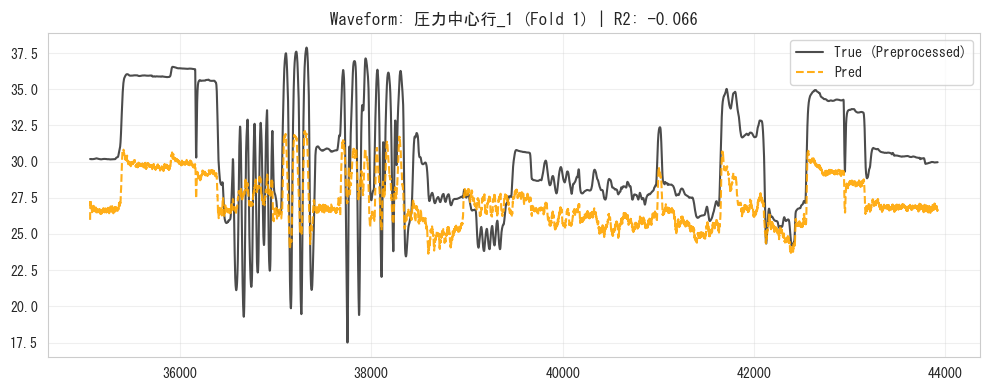


✅ Training Complete. Results saved to self.df_result (Includes Train & Test)

📊 RESULTS SUMMARY
圧力中心行_1              | R2: -0.066 | MAE:     3.40 | RMSE:     3.86


In [6]:
# ==========================================
# STEP 3: 実際のデータで実行
# ==========================================

# --- 設定 ---
CONFIG_HIERARCHICAL = {
    # 前処理
    'enable_smoothing': True,
    'enable_detrending': False,
    'enable_bias_sub': True,
    'scale_y': False,
    
    # 可視化
    'show_plots': True,
    'show_importance': False,  # 重要度プロットは省略
    
    # パラメータ
    'smooth_window': 15,
    'bias_window': 60,
    'detrend_window': 300,
    'cv_splits': 3,
    
    # Hierarchical設定
    'model_type': 'hierarchical',
    'n_components': 'auto',  # または具体的な数値 (例: 15)
    'use_gain': True,
    'use_offset': True,
}

# --- データ準備 ---
# あなたのコード
mock_sensor_cols = ['subject_id',
    'F1', 'F2', 'F3', 'F4', 'steer', 'pedal', 'W', 
    'F1_fnorm', 'F2_fnorm', 'F3_fnorm', 'F4_fnorm',
    'COP_X_phys', 'COP_Y_phys', 'phys_pitch', 'phys_roll', 'phys_torsion',
    'COP_radius', 'COP_angle', 'op_magnitude', 'interact_steer_pedal',
    'steer_COPx', 'steer_COPy', 'pedal_COPx', 'pedal_COPy',
    'COP_X_phys_vel', 'COP_Y_phys_vel', 'W_vel', 'phys_pitch_vel',
    'phys_roll_vel', 'steer_vel', 'pedal_vel', 'interact_steer_vel_COP',
    'F1_hysteresis', 'F2_hysteresis', 'F3_hysteresis', 'F4_hysteresis',
    'W_hysteresis', 'COP_X_phys_hysteresis', 'COP_Y_phys_hysteresis',
    'Interaction_COPX_W', 'Interaction_COPY_W', 
    'W_Power', 'COP_X_phys_Power', 'COP_Y_phys_Power',
    'COP_X_phys_vel_integ', 'COP_X_phys_vel_ma30', 
    'COP_Y_phys_vel_integ', 'COP_Y_phys_vel_ma30', 
    'W_vel_integ', 'W_vel_ma30',
    'phys_pitch_vel_integ', 'phys_pitch_vel_ma30', 
    'phys_roll_vel_integ', 'phys_roll_vel_ma30',
    'F1_init', 'F2_init', 'F3_init', 'F4_init',
    'W_init', 'LR_balance_init', 'FB_balance_init'
]

target_features_A = [
    '圧力中心行_1', 
    # '圧力中心列_1', 
    # '圧力中心列_2', 
    # '接触 %_1', '荷重(N)_1', '荷重(N)_2', 
    # '平均圧力_2', 
    # '平均圧力_1'
]

# データ抽出
available_cols = df_all.columns.tolist()
X_cols = [c for c in mock_sensor_cols if c in available_cols]
Y_cols = [c for c in target_features_A if c in available_cols]

df_raw = df_all[X_cols + Y_cols].dropna()
X_raw = df_raw[X_cols]
y_raw = df_raw[Y_cols]

print(f"✅ Data loaded: {len(df_raw)} samples")
print(f"   Features: {len(X_cols)-1} (excluding subject_id)")
print(f"   Targets: {len(Y_cols)}")
print(f"   Subjects: {sorted(X_raw['subject_id'].unique())}")


# ==========================================
# STEP 4: 実行（既存パイプラインを使う場合）
# ==========================================

# 方法A: 既存のSubjectAwarePipelineを使う（推奨）
pipeline = SubjectAwarePipeline(CONFIG_HIERARCHICAL)

# テスト被験者を1人選ぶ（例: subject_id=16）
holdout_subject = 16

print(f"\n{'='*60}")
print(f"🚀 Training Hierarchical PLS Model")
print(f"   Train subjects: {[s for s in X_raw['subject_id'].unique() if s != holdout_subject]}")
print(f"   Test subject: {holdout_subject}")
print('='*60)

pipeline.fit(X_raw, y_raw, holdout_subject_ids=[holdout_subject])

# 結果確認
print("\n" + "="*60)
print("📊 RESULTS SUMMARY")
print("="*60)

df_result = pipeline.df_result
df_test = df_result[df_result['data_type'] == 'test']

for target_col in Y_cols:
    true_col = f"{target_col}_true"
    pred_col = f"{target_col}_pred"

    if true_col in df_test.columns and pred_col in df_test.columns:
                # ★修正: 評価用のデータフレームを作り、NaNがある行を削除する
                # (TrueかPredどちらかがNaNなら、そのサンプルは評価から外す)
                df_eval = df_test[[true_col, pred_col]].dropna()
                
                if len(df_eval) == 0:
                    print(f"{target_col:20s} | Skipped (No valid data after dropna)")
                    continue

                try:
                    r2 = r2_score(df_eval[true_col], df_eval[pred_col])
                    mae = mean_absolute_error(df_eval[true_col], df_eval[pred_col])
                    rmse = np.sqrt(mean_squared_error(df_eval[true_col], df_eval[pred_col]))
                    
                    print(f"{target_col:20s} | R2: {r2:6.3f} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f}")
                except Exception as e:
                    print(f"{target_col:20s} | Error: {e}")
    



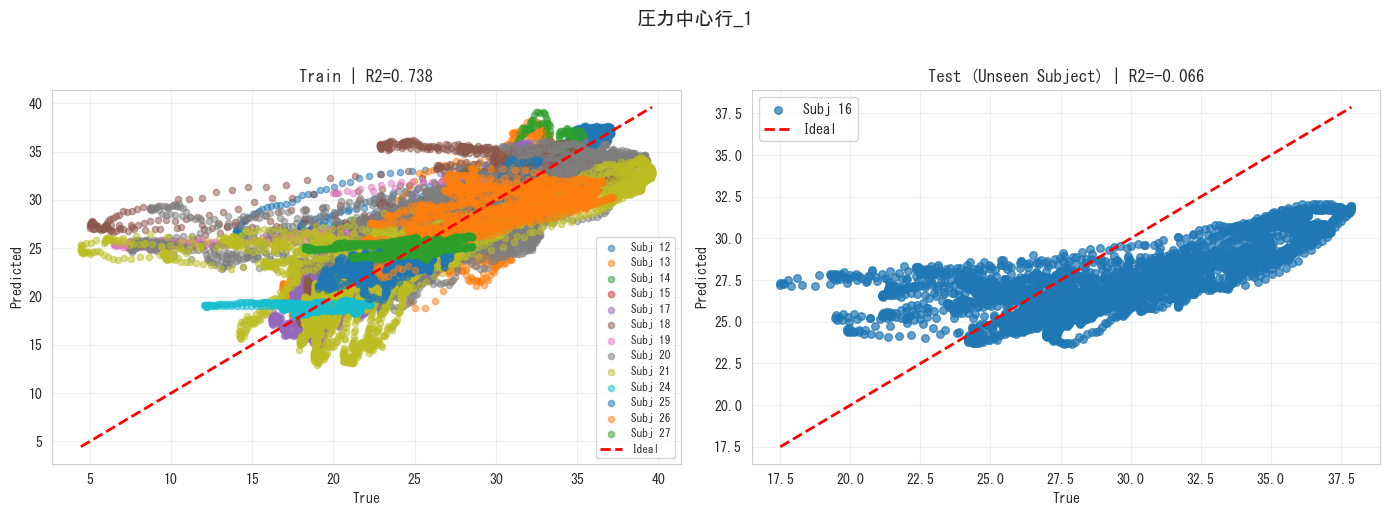


Training: STANDARD
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
   Target: 圧力中心行_1         | Test R2: 0.2733

✅ Training Complete. Results saved to self.df_result (Includes Train & Test)

Training: HIERARCHICAL
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
    [Auto-tuning] Testing n_components from 1 to 20...
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.170, 1.398], median=1.020
    Offset: [-12.906, 20.389], median=-0.578
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.140, 1.524], median=0.832
    Offset: [-15.490, 15.197], median=4.826
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.151, 1.602], median=0.848
    Offset: [-

In [7]:
# ==========================================
# STEP 6: 診断プロット（オプション）
# ==========================================
def plot_subject_comparison(df_result, target_col):
    """
    被験者ごとの予測精度を可視化
    """
    true_col = f"{target_col}_true"
    pred_col = f"{target_col}_pred"
    
    if true_col not in df_result.columns:
        return
    
    # Train/Test分離
    df_train = df_result[df_result['data_type'] == 'train']
    df_test = df_result[df_result['data_type'] == 'test']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Train
    if len(df_train) > 0:
        for subj in df_train['subject_id'].unique():
            df_subj = df_train[df_train['subject_id'] == subj]
            axes[0].scatter(df_subj[true_col], df_subj[pred_col], 
                          alpha=0.5, label=f'Subj {subj}', s=20)
        
        r2_train = r2_score(df_train[true_col], df_train[pred_col])
        axes[0].plot([df_train[true_col].min(), df_train[true_col].max()],
                     [df_train[true_col].min(), df_train[true_col].max()],
                     'r--', lw=2, label='Ideal')
        axes[0].set_title(f'Train | R2={r2_train:.3f}')
        axes[0].set_xlabel('True')
        axes[0].set_ylabel('Predicted')
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)
    
    # Test
    if len(df_test) > 0:
        for subj in df_test['subject_id'].unique():
            df_subj = df_test[df_test['subject_id'] == subj]
            axes[1].scatter(df_subj[true_col], df_subj[pred_col],
                          alpha=0.7, label=f'Subj {subj}', s=30)
        
        r2_test = r2_score(df_test[true_col], df_test[pred_col])
        axes[1].plot([df_test[true_col].min(), df_test[true_col].max()],
                     [df_test[true_col].min(), df_test[true_col].max()],
                     'r--', lw=2, label='Ideal')
        axes[1].set_title(f'Test (Unseen Subject) | R2={r2_test:.3f}')
        axes[1].set_xlabel('True')
        axes[1].set_ylabel('Predicted')
        axes[1].legend(fontsize=10)
        axes[1].grid(alpha=0.3)
    
    plt.suptitle(f'{target_col}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 全ターゲットについて診断プロット
for target in Y_cols:
    plot_subject_comparison(pipeline.df_result, target)


# ==========================================
# STEP 7: 標準PLSとの比較
# ==========================================
def compare_standard_vs_hierarchical(X_raw, y_raw, holdout_id=16):
    """
    標準PLSとHierarchicalPLSを比較
    """
    results = {}
    
    for model_type in ['standard', 'hierarchical']:
        print(f"\n{'='*60}")
        print(f"Training: {model_type.upper()}")
        print('='*60)
        
        config = CONFIG_HIERARCHICAL.copy()
        config['model_type'] = model_type
        config['show_plots'] = False
        config['show_importance'] = False
        
        pipeline = SubjectAwarePipeline(config)
        pipeline.fit(X_raw, y_raw, holdout_subject_ids=[holdout_id])
        
        df_test = pipeline.df_result[pipeline.df_result['data_type'] == 'test']
        
        r2_scores = {}
        for target in Y_cols:
            true_col = f"{target}_true"
            pred_col = f"{target}_pred"
            if true_col in df_test.columns:
                r2_scores[target] = r2_score(df_test[true_col], df_test[pred_col])
        
        results[model_type] = r2_scores
    
    # 比較表
    print("\n" + "="*60)
    print("COMPARISON: Standard PLS vs Hierarchical PLS")
    print("="*60)
    df_comp = pd.DataFrame(results).T
    df_comp['Average'] = df_comp.mean(axis=1)
    print(df_comp.to_string())
    
    # 改善度
    if 'standard' in results and 'hierarchical' in results:
        print("\n📈 Improvement (Hierarchical - Standard):")
        improvements = []
        for target in results['standard'].keys():
            delta = results['hierarchical'][target] - results['standard'][target]
            improvements.append(delta)
            print(f"  {target:20s}: {delta:+.4f}")
        print(f"\n  Average Improvement: {np.mean(improvements):+.4f}")
    
    return results

# 実行
comparison_results = compare_standard_vs_hierarchical(X_raw, y_raw, holdout_id=16)


Target: 圧力中心行_1
🔬 Training Data Performance Comparison

[1/2] Training Standard PLS...
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
   Target: 圧力中心行_1         | Test R2: 0.2733

✅ Training Complete. Results saved to self.df_result (Includes Train & Test)

[2/2] Training Hierarchical PLS...
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
    [Auto-tuning] Testing n_components from 1 to 20...
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.170, 1.398], median=1.020
    Offset: [-12.906, 20.389], median=-0.578
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.140, 1.524], median=0.832
    Offset: [-15.490, 15.197], median=4.826
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subje

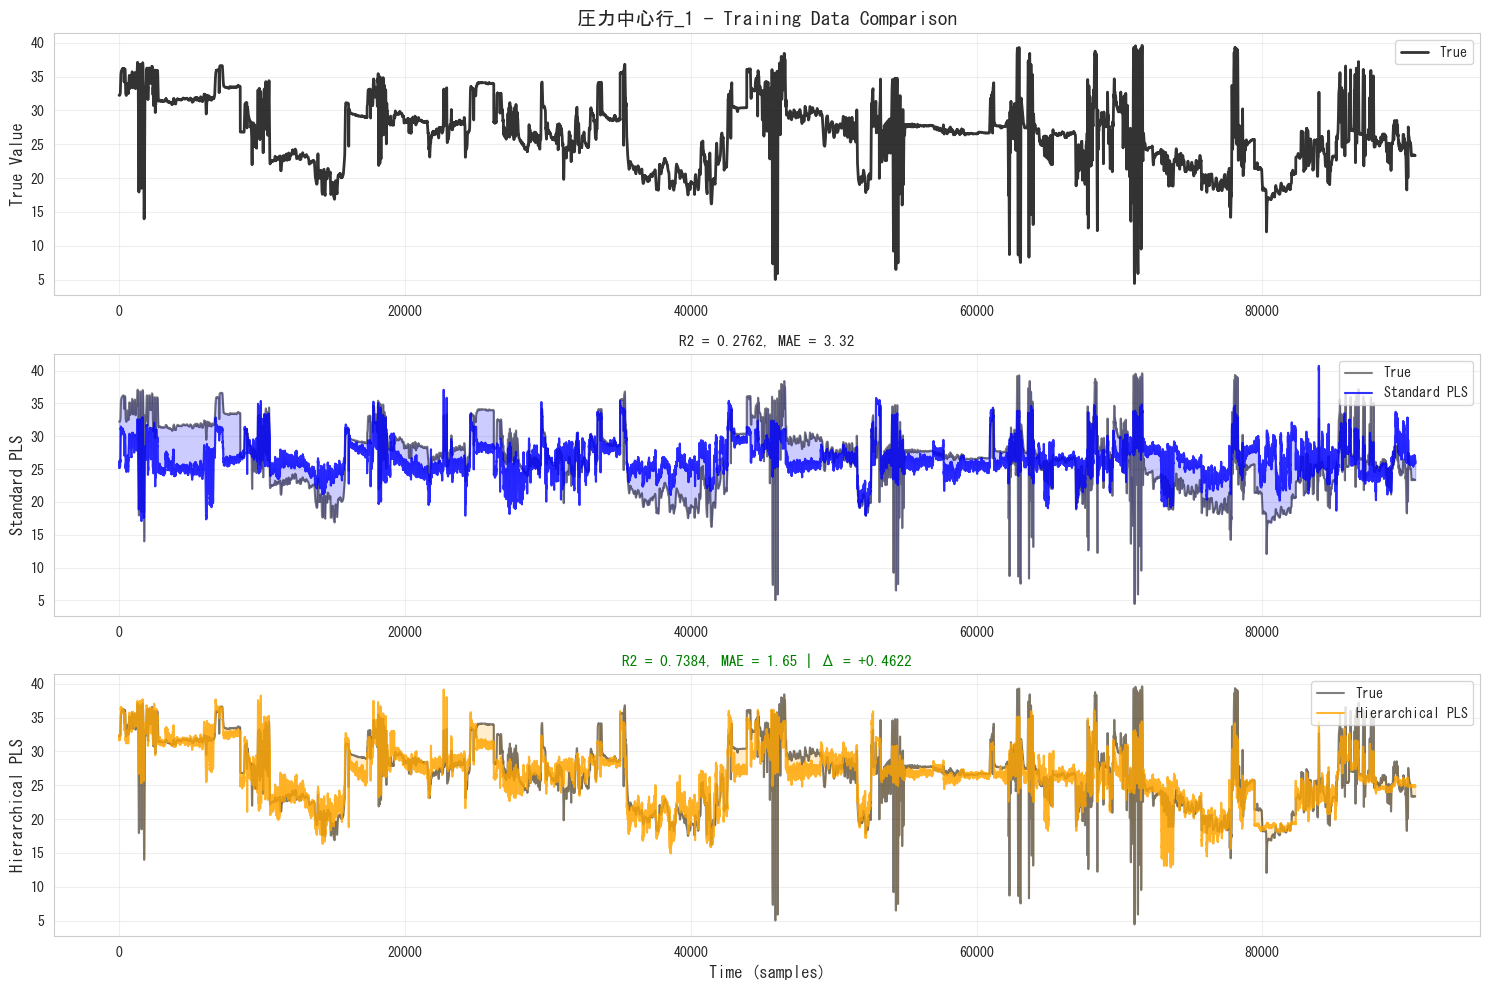

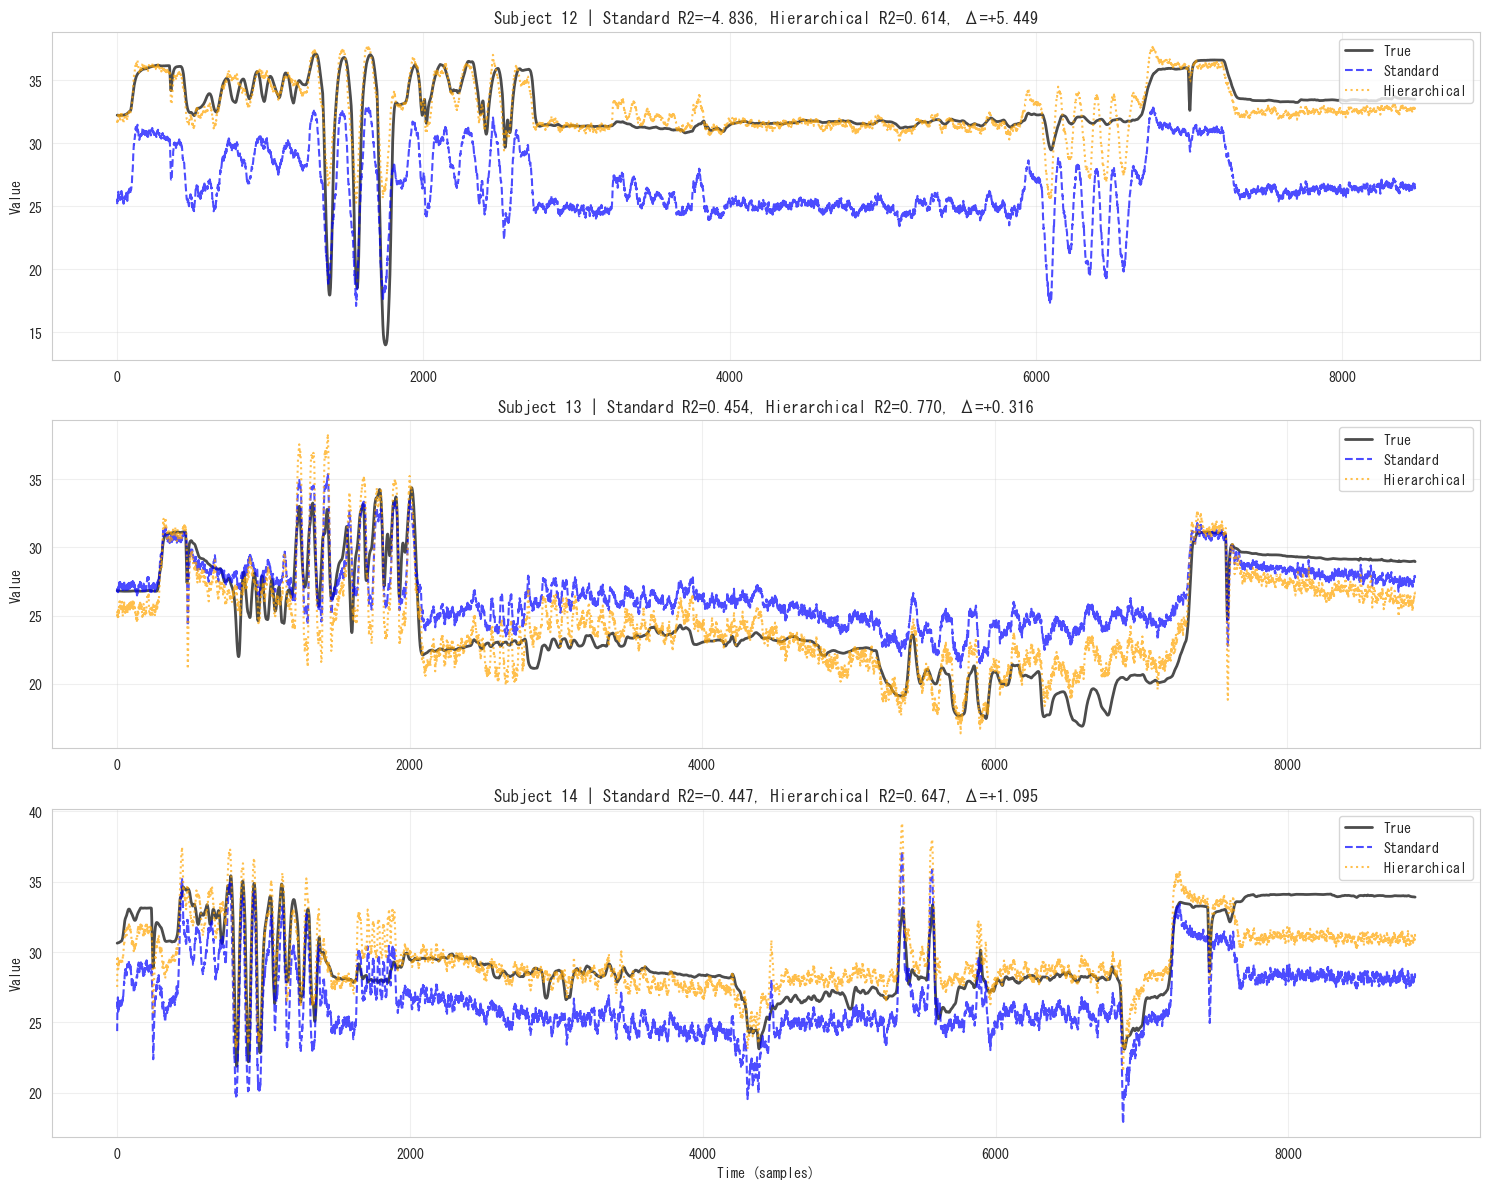

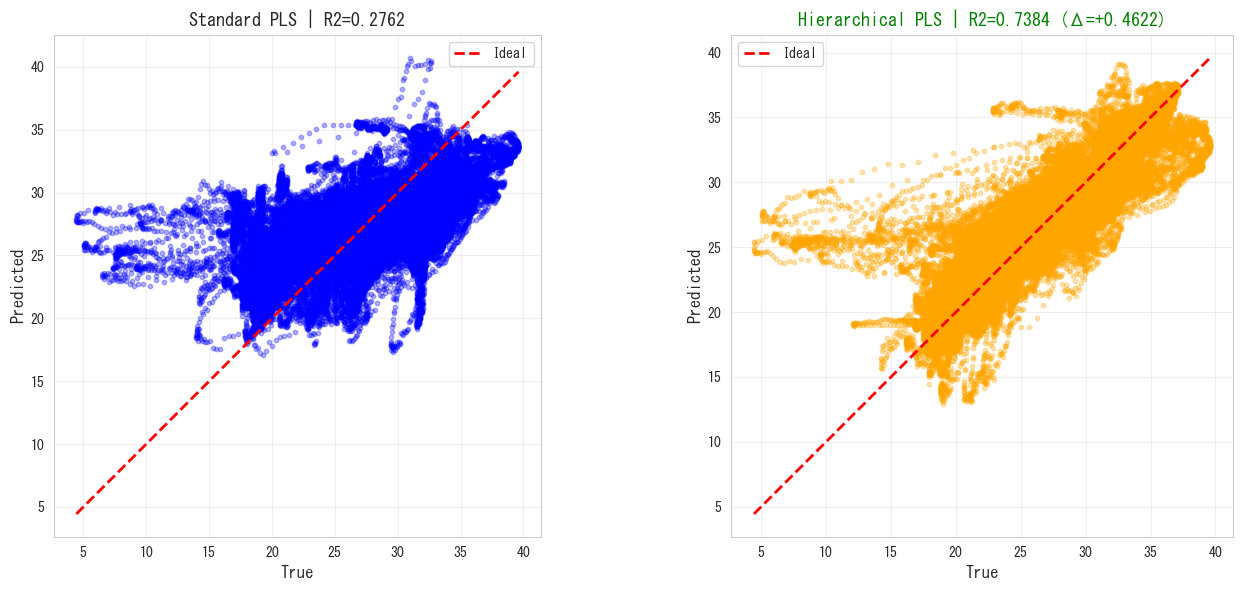

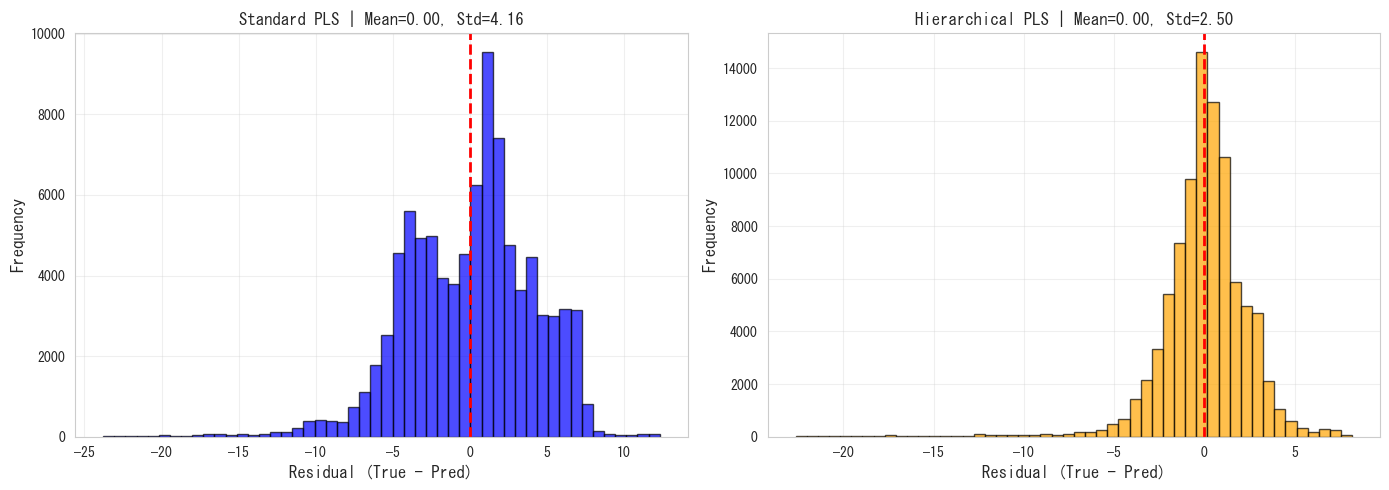


🚀 Quick Training Data Comparison
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
   Target: 圧力中心行_1         | Test R2: 0.2733

✅ Training Complete. Results saved to self.df_result (Includes Train & Test)
🚀 Pipeline Start | Plots: False | Importance: False
🚀 分割ロジック: Hold-out Subject Mode (Test IDs: [16])

--- Fold 1 ---
    [Auto-tuning] Testing n_components from 1 to 20...
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.170, 1.398], median=1.020
    Offset: [-12.906, 20.389], median=-0.578
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.140, 1.524], median=0.832
    Offset: [-15.490, 15.197], median=4.826
    [Stage 1] Training Global PLS (n_components=1)...
    [Stage 2] Fitting Subject-specific corrections...
    Gain: [0.151, 1.602], median=0.848
    Offset: [-19.527, 19

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================================
# 訓練データでの Standard vs Hierarchical 比較
# ==========================================

def compare_train_performance(X_raw, y_raw, holdout_subject=16, target_col='圧力中心行_1'):
    """
    訓練被験者（学習に使ったデータ）で Standard と Hierarchical を比較
    """
    
    print("="*60)
    print("🔬 Training Data Performance Comparison")
    print("="*60)
    
    # --- Standard PLS の学習 ---
    print("\n[1/2] Training Standard PLS...")
    config_std = CONFIG_HIERARCHICAL.copy()
    config_std['model_type'] = 'standard'
    config_std['show_plots'] = False
    config_std['show_importance'] = False
    
    pipeline_std = SubjectAwarePipeline(config_std)
    pipeline_std.fit(X_raw, y_raw, holdout_subject_ids=[holdout_subject])
    
    # --- Hierarchical PLS の学習 ---
    print("\n[2/2] Training Hierarchical PLS...")
    config_hier = CONFIG_HIERARCHICAL.copy()
    config_hier['show_plots'] = False
    config_hier['show_importance'] = False
    
    pipeline_hier = SubjectAwarePipeline(config_hier)
    pipeline_hier.fit(X_raw, y_raw, holdout_subject_ids=[holdout_subject])
    
    # --- 訓練データを抽出 ---
    df_train_std = pipeline_std.df_result[pipeline_std.df_result['data_type'] == 'train']
    df_train_hier = pipeline_hier.df_result[pipeline_hier.df_result['data_type'] == 'train']
    
    # ターゲット列
    true_col = f"{target_col}_true"
    pred_col = f"{target_col}_pred"
    
    # NaN除去
    df_train_std_clean = df_train_std[[true_col, pred_col, 'subject_id', 'time']].dropna()
    df_train_hier_clean = df_train_hier[[true_col, pred_col, 'subject_id', 'time']].dropna()
    
    # 共通のインデックスで揃える（念のため）
    common_idx = df_train_std_clean.index.intersection(df_train_hier_clean.index)
    df_std = df_train_std_clean.loc[common_idx]
    df_hier = df_train_hier_clean.loc[common_idx]
    
    # --- スコア計算 ---
    y_true = df_std[true_col].values
    y_pred_std = df_std[pred_col].values
    y_pred_hier = df_hier[pred_col].values
    
    r2_std = r2_score(y_true, y_pred_std)
    r2_hier = r2_score(y_true, y_pred_hier)
    mae_std = mean_absolute_error(y_true, y_pred_std)
    mae_hier = mean_absolute_error(y_true, y_pred_hier)
    rmse_std = np.sqrt(mean_squared_error(y_true, y_pred_std))
    rmse_hier = np.sqrt(mean_squared_error(y_true, y_pred_hier))
    
    print("\n" + "="*60)
    print(f"📊 Training Data Results - {target_col}")
    print("="*60)
    print(f"{'Metric':<15} {'Standard':>12} {'Hierarchical':>15} {'Δ':>10}")
    print("-"*60)
    print(f"{'R2':<15} {r2_std:>12.4f} {r2_hier:>15.4f} {r2_hier-r2_std:>+10.4f}")
    print(f"{'MAE':<15} {mae_std:>12.2f} {mae_hier:>15.2f} {mae_hier-mae_std:>+10.2f}")
    print(f"{'RMSE':<15} {rmse_std:>12.2f} {rmse_hier:>15.2f} {rmse_hier-rmse_std:>+10.2f}")
    print("="*60)
    
    # --- 被験者ごとの改善度 ---
    print("\n📊 Per-Subject Improvement:")
    print("-"*60)
    
    subject_results = []
    for subj in df_std['subject_id'].unique():
        mask = df_std['subject_id'] == subj
        
        y_subj = y_true[mask]
        pred_std_subj = y_pred_std[mask]
        pred_hier_subj = y_pred_hier[mask]
        
        if len(y_subj) > 10:  # 最低10サンプル
            r2_std_subj = r2_score(y_subj, pred_std_subj)
            r2_hier_subj = r2_score(y_subj, pred_hier_subj)
            improvement = r2_hier_subj - r2_std_subj
            
            subject_results.append({
                'Subject': int(subj),
                'R2_Standard': r2_std_subj,
                'R2_Hierarchical': r2_hier_subj,
                'Improvement': improvement,
                'N_samples': len(y_subj)
            })
    
    df_subject_results = pd.DataFrame(subject_results).sort_values('Improvement')
    print(df_subject_results.to_string(index=False))
    
    # --- 可視化1: 波形プロット（全体） ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    
    # True値
    axes[0].plot(y_true, label='True', color='black', linewidth=2, alpha=0.8)
    axes[0].set_ylabel('True Value', fontsize=12)
    axes[0].set_title(f'{target_col} - Training Data Comparison', fontsize=14, fontweight='bold')
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    
    # Standard PLS
    axes[1].plot(y_true, label='True', color='black', linewidth=1.5, alpha=0.5)
    axes[1].plot(y_pred_std, label='Standard PLS', color='blue', linewidth=1.5, alpha=0.8)
    axes[1].fill_between(range(len(y_true)), y_true, y_pred_std, alpha=0.2, color='blue')
    axes[1].set_ylabel('Standard PLS', fontsize=12)
    axes[1].set_title(f'R2 = {r2_std:.4f}, MAE = {mae_std:.2f}', fontsize=11)
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
    
    # Hierarchical PLS
    axes[2].plot(y_true, label='True', color='black', linewidth=1.5, alpha=0.5)
    axes[2].plot(y_pred_hier, label='Hierarchical PLS', color='orange', linewidth=1.5, alpha=0.8)
    axes[2].fill_between(range(len(y_true)), y_true, y_pred_hier, alpha=0.2, color='orange')
    axes[2].set_ylabel('Hierarchical PLS', fontsize=12)
    axes[2].set_xlabel('Time (samples)', fontsize=12)
    axes[2].set_title(f'R2 = {r2_hier:.4f}, MAE = {mae_hier:.2f} | Δ = {r2_hier-r2_std:+.4f}', 
                     fontsize=11, color='green' if r2_hier > r2_std else 'red')
    axes[2].legend(loc='upper right')
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- 可視化2: 被験者別の波形（サンプル） ---
    sample_subjects = df_std['subject_id'].unique()[:3]  # 最初の3被験者
    
    fig, axes = plt.subplots(len(sample_subjects), 1, figsize=(15, 4*len(sample_subjects)))
    if len(sample_subjects) == 1:
        axes = [axes]
    
    for idx, subj in enumerate(sample_subjects):
        mask = df_std['subject_id'] == subj
        
        y_subj = y_true[mask]
        pred_std_subj = y_pred_std[mask]
        pred_hier_subj = y_pred_hier[mask]
        
        r2_std_subj = r2_score(y_subj, pred_std_subj)
        r2_hier_subj = r2_score(y_subj, pred_hier_subj)
        
        axes[idx].plot(y_subj, label='True', color='black', linewidth=2, alpha=0.7)
        axes[idx].plot(pred_std_subj, label='Standard', color='blue', linewidth=1.5, alpha=0.7, linestyle='--')
        axes[idx].plot(pred_hier_subj, label='Hierarchical', color='orange', linewidth=1.5, alpha=0.7, linestyle=':')
        
        axes[idx].set_title(f'Subject {int(subj)} | Standard R2={r2_std_subj:.3f}, Hierarchical R2={r2_hier_subj:.3f}, Δ={r2_hier_subj-r2_std_subj:+.3f}',
                           fontsize=12)
        axes[idx].set_ylabel('Value')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(alpha=0.3)
    
    axes[-1].set_xlabel('Time (samples)')
    plt.tight_layout()
    plt.show()
    
    # --- 可視化3: 散布図比較 ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Standard
    axes[0].scatter(y_true, y_pred_std, alpha=0.3, s=10, c='blue')
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', lw=2, label='Ideal')
    axes[0].set_xlabel('True', fontsize=12)
    axes[0].set_ylabel('Predicted', fontsize=12)
    axes[0].set_title(f'Standard PLS | R2={r2_std:.4f}', fontsize=13)
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_aspect('equal', adjustable='box')
    
    # Hierarchical
    axes[1].scatter(y_true, y_pred_hier, alpha=0.3, s=10, c='orange')
    axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 
                 'r--', lw=2, label='Ideal')
    axes[1].set_xlabel('True', fontsize=12)
    axes[1].set_ylabel('Predicted', fontsize=12)
    axes[1].set_title(f'Hierarchical PLS | R2={r2_hier:.4f} (Δ={r2_hier-r2_std:+.4f})', 
                     fontsize=13, color='green' if r2_hier > r2_std else 'red')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()
    
    # --- 可視化4: 残差分布 ---
    residual_std = y_true - y_pred_std
    residual_hier = y_true - y_pred_hier
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(residual_std, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_xlabel('Residual (True - Pred)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'Standard PLS | Mean={np.mean(residual_std):.2f}, Std={np.std(residual_std):.2f}', 
                     fontsize=12)
    axes[0].grid(alpha=0.3)
    
    axes[1].hist(residual_hier, bins=50, alpha=0.7, color='orange', edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residual (True - Pred)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].set_title(f'Hierarchical PLS | Mean={np.mean(residual_hier):.2f}, Std={np.std(residual_hier):.2f}', 
                     fontsize=12)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df_subject_results


# ==========================================
# 実行
# ==========================================
# 全ターゲットについて比較
for target_col in Y_cols:
    print(f"\n{'='*60}")
    print(f"Target: {target_col}")
    print('='*60)
    
    try:
        results = compare_train_performance(X_raw, y_raw, holdout_subject=16, target_col=target_col)
    except Exception as e:
        print(f"⚠️ Error: {e}")
        import traceback
        traceback.print_exc()


# ==========================================
# 簡易版: 数値だけ確認したい場合
# ==========================================

def quick_train_comparison(X_raw, y_raw, holdout_subject=16):
    """
    数値だけサクッと確認
    """
    print("\n" + "="*60)
    print("🚀 Quick Training Data Comparison")
    print("="*60)
    
    results_summary = []
    
    for model_type in ['standard', 'hierarchical']:
        config = CONFIG_HIERARCHICAL.copy()
        config['model_type'] = model_type
        config['show_plots'] = False
        config['show_importance'] = False
        
        pipeline = SubjectAwarePipeline(config)
        pipeline.fit(X_raw, y_raw, holdout_subject_ids=[holdout_subject])
        
        df_train = pipeline.df_result[pipeline.df_result['data_type'] == 'train']
        
        for target_col in Y_cols:
            true_col = f"{target_col}_true"
            pred_col = f"{target_col}_pred"
            
            if true_col in df_train.columns:
                df_clean = df_train[[true_col, pred_col]].dropna()
                if len(df_clean) > 0:
                    r2 = r2_score(df_clean[true_col], df_clean[pred_col])
                    results_summary.append({
                        'Model': model_type.capitalize(),
                        'Target': target_col,
                        'R2': r2
                    })
    
    df_summary = pd.DataFrame(results_summary)
    df_pivot = df_summary.pivot(index='Target', columns='Model', values='R2')
    df_pivot['Improvement'] = df_pivot['Hierarchical'] - df_pivot['Standard']
    
    print(df_pivot.to_string())
    print("\n平均改善度: {:.4f}".format(df_pivot['Improvement'].mean()))
    
    return df_pivot

# 実行
summary = quick_train_comparison(X_raw, y_raw, holdout_subject=16)